In [1]:
import pytensor
print('pytensor: %s' % pytensor.__version__)

pytensor: 2.38.2


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
#we want repeatable results, so we fix random seed,seed is used for random weight initialisation
np.random.seed(10)
torch.manual_seed(10)

# load data from data.csv file into ds - numpy array
df = pd.read_csv('haberman.csv')

#prepare labels in y column,change values into -1 or 1
df['y'] = df['y'].map({1: -1, 2: 1})
print(df.head(10))

   x1  x2  x3  y
0  30  64   1 -1
1  30  62   3 -1
2  30  65   0 -1
3  31  59   2 -1
4  31  65   4 -1
5  33  58  10 -1
6  33  60   0 -1
7  34  59   0  1
8  34  66   9  1
9  34  58  30 -1


In [4]:
X = df.iloc[:,0:3]
Y = df.iloc[:,3]

# normalize X data
X=(X-X.mean())/X.std()
X.head()

,x1,x2,x3
0,-2.078735,0.353006,-0.420903
1,-2.078735,-0.262492,-0.142725
2,-2.078735,0.660755,-0.559991
3,-1.986172,-1.185738,-0.281814
4,-1.986172,0.660755,-0.003636


In [5]:
#Split data into TrainingSet[input (X) and output (Y) variables]
# and TestingSet[input (X2) and output (Y2) variables]

#Calculate number of rows in the training set
trainingSetSize=int(df.shape[0]*0.8)
print("Number of rows in training set",trainingSetSize)

X1 = X.iloc[:trainingSetSize,:]
Y1 = Y.iloc[:trainingSetSize]

X2 = X.iloc[trainingSetSize: ,:]
Y2= Y.iloc[trainingSetSize:]

Number of rows in training set 244


In [8]:
from IPython.display import display, Image
from matplotlib import pyplot
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

def rmse(y_pred, y_true):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

#Create nn model
#use Sequential class which is a linear stack of Layers
class NNModel(nn.Module):
    def __init__(self):
        super(NNModel, self).__init__()

        #Define the structure of each layer in nn
        #For each layer set info about:
        #number of neurons
        #activation function type:linear, relu,sigmoid, tanh

        #Input layer (3 neurons) + 1st hidden layer
        self.layer1 = nn.Linear(3, 4)
        self.bn1 = nn.BatchNorm1d(4)

        #2nd hidden layaer
        self.layer2 = nn.Linear(4, 3)
        self.bn2 = nn.BatchNorm1d(3)

        #Output layaer
        self.output = nn.Linear(3, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.bn1(x)

        x = self.tanh(self.layer2(x))
        x = self.bn2(x)

        x = self.tanh(self.output(x))
        return x

#compile model
#rmse - custom metric defined above
model = NNModel()

#Plot structure of the nn model
criterion = nn.BCEWithLogitsLoss()   # binary classification loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
summary(model, input_size=(1, 3))


Layer (type:depth-idx)                   Output Shape              Param #
NNModel                                  [1, 1]                    --
├─Linear: 1-1                            [1, 4]                    16
├─ReLU: 1-2                              [1, 4]                    --
├─BatchNorm1d: 1-3                       [1, 4]                    8
├─Linear: 1-4                            [1, 3]                    15
├─Tanh: 1-5                              [1, 3]                    --
├─BatchNorm1d: 1-6                       [1, 3]                    6
├─Linear: 1-7                            [1, 1]                    4
├─Tanh: 1-8                              [1, 1]                    --
Total params: 49
Trainable params: 49
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

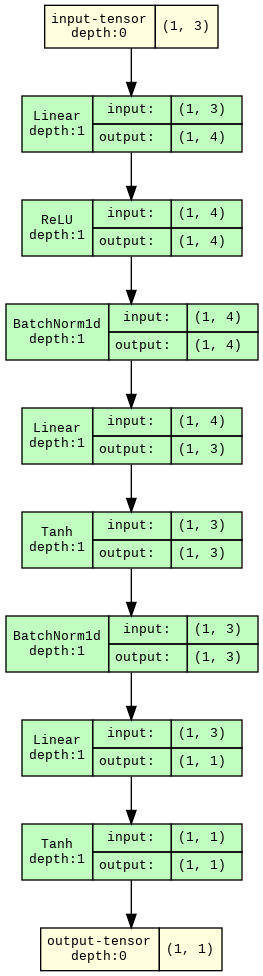

In [10]:
from torchview import draw_graph
from IPython.display import Image
Image("model_architecture.png")
#Test input to plot the graph of the model
graph = draw_graph(
    model,
    input_size=(1, 3),   # batch_size=1, 3 features
    expand_nested=True
)

graph.visual_graph.render("model_architecture", format="png")
Image("model_architecture.png")

In [11]:
from scipy import stats

X_tensor = torch.tensor(X1.values, dtype=torch.float32)
Y_tensor = torch.tensor(Y1.values, dtype=torch.float32).view(-1, 1)
criterion = nn.MSELoss()              # suitable for targets -1 / +1
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 450
batch_size = 10

dataset = torch.utils.data.TensorDataset(X_tensor, Y_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

#Evaluate the model on the training set
model.eval()
with torch.no_grad():
    predictions = model(X_tensor)
    loss_value = criterion(predictions, Y_tensor)
print("Loss function value - training set:", loss_value.item())

Epoch 50/450, Loss: 16.5534
Epoch 100/450, Loss: 16.2714
Epoch 150/450, Loss: 16.9843
Epoch 200/450, Loss: 16.0596
Epoch 250/450, Loss: 16.5713
Epoch 300/450, Loss: 16.3366
Epoch 350/450, Loss: 16.3135
Epoch 400/450, Loss: 15.9534
Epoch 450/450, Loss: 16.0865
Loss function value - training set: 0.6294862031936646


In [12]:
#Predict values in the training set
with torch.no_grad():
    Y1_pred = model(X_tensor)
    Y1_pred = Y1_pred.numpy()

#Assign category -1 or 1 basing on the predicted values - training set
Y1_pred[Y1_pred >= 0] = 1
Y1_pred[Y1_pred < 0] = -1
Y_true = Y1.values.reshape(-1,1)

Y_true_flat = Y_true.reshape(-1)
Y1_pred_flat = Y1_pred.reshape(-1)
Y_true_flat = Y_true_flat.astype(int)
Y1_pred_flat = Y1_pred_flat.astype(int)

unique, counts = np.unique(Y_true, return_counts=True)
print("Number of obs. per category in Y1 - training set:")
print(np.vstack((unique, counts)).T)

correct = np.sum(Y1_pred_flat == Y_true_flat)
success_rate = 100.0 * correct / len(Y_true_flat)
print("Success rate(%) - training set:", success_rate)

Number of obs. per category in Y1 - training set:
[[ -1 179]
 [  1  65]]
Success rate(%) - training set: 79.09836065573771


In [13]:
#Make predictions on the testing set
#Y2_pred is pytorch tensor, so we need to convert it to numpy array to assign category -1 or 1 basing on the predicted values - testing set
X2_tensor = torch.tensor(X2.values, dtype=torch.float32)
Y2_tensor = torch.tensor(Y2.values, dtype=torch.float32).view(-1, 1)

model.eval()  # very important (turns off BatchNorm training behavior)

with torch.no_grad():  # disables gradient tracking
    Y2_pred = model(X2_tensor)
    Y2_pred = Y2_pred.numpy()

#Assign category -1 or 1 basing on the predicted values - testing set
Y2_pred[Y2_pred >= 0] = 1
Y2_pred[Y2_pred < 0] = -1

Y2_true = Y2.values.reshape(-1, 1)

success_rate = 100 * np.sum(Y2_pred == Y2_true) / len(Y2_true)
print("Success rate(%) - testing set:", success_rate)

unique, counts = np.unique(Y2_true, return_counts=True)

print("Number of obs. per category in Y2 - testing set:")
print(np.vstack((unique, counts)).T)
print("\n\n")

Success rate(%) - testing set: 74.19354838709677
Number of obs. per category in Y2 - testing set:
[[-1 46]
 [ 1 16]]



